Processing 1478 rows.


/Users/oscar/Desktop/Projects/birdcleff-2026/venv/lib/python3.11/site-packages/transformers/audio_utils.py:538: UserWarning: At least one mel filter has all zero values. The value for `num_mel_filters` (128) may be set too high. Or, the value for `num_frequency_bins` (257) may be set too low.
  warnings.warn(


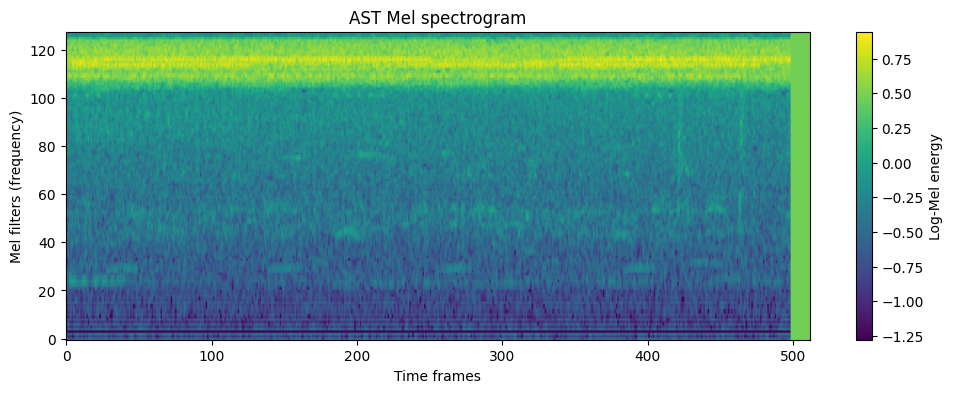

In [3]:
import matplotlib.pyplot as plt

from src.data_manager import DataManager
from src.config import Config


config = Config()
data_manager = DataManager(config)

for batch in data_manager:
    spectrogram = batch['input_values'][0]
    spectrogram = spectrogram.T.numpy()
    plt.figure(figsize=(12, 4))
    plt.imshow(spectrogram, aspect='auto', origin='lower', cmap='viridis')
    plt.colorbar(label='Log-Mel energy')
    plt.title('AST Mel spectrogram')
    plt.xlabel('Time frames')
    plt.ylabel('Mel filters (frequency)')
    plt.show()
    break

In [ ]:
import torch
import numpy as np

from transformers import ASTForAudioClassification

from src.config import Config
from src.data_manager import DataManager

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
config = Config()
data_manager = DataManager(config)
checkpoint_path = 'data/checkpoints/checkpoint-840'
model = ASTForAudioClassification.from_pretrained(checkpoint_path)
model.eval()
model.to(device)  # type: ignore
filename = 'BC2026_Train_0022_S22_20211114_014500'
seconds_per_sample = 5

with torch.no_grad():
    input = DataManager.get_inference_input(
        config,
        f'./data/train_soundscapes/{filename}.ogg',
        seconds_per_sample
    ).to(device)
    logits = model(input).logits
    probs = torch.nn.functional.softmax(logits, dim=-1)

print(probs)

Processing 1478 rows.


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

tensor([[6.1048e-04, 5.7259e-04, 1.7775e-04, 1.1553e-03, 7.8963e-04, 6.0722e-04,
         7.2973e-04, 5.3891e-04, 1.7512e-04, 2.7806e-04, 2.1586e-04, 3.1084e-04,
         1.1460e-03, 2.3274e-04, 2.2840e-04, 3.9301e-04, 2.2750e-04, 3.3084e-04,
         4.4420e-04, 7.6987e-04, 5.7848e-04, 2.8906e-04, 1.6251e-04, 3.3966e-04,
         9.4240e-05, 4.4038e-04, 3.7130e-04, 2.2868e-04, 2.9217e-04, 5.5286e-04,
         1.9785e-04, 3.1080e-04, 2.0041e-04, 4.3379e-04, 3.9168e-04, 4.4463e-04,
         3.0864e-04, 3.8527e-04, 1.7012e-04, 7.1281e-04, 4.5101e-04, 1.2310e-04,
         7.1249e-04, 5.0506e-04, 3.1969e-04, 1.5463e-04, 6.4422e-04, 2.7265e-04,
         1.9215e-04, 1.9663e-04, 7.4908e-04, 4.4401e-04, 1.9271e-01, 4.8783e-04,
         3.0939e-04, 2.7726e-04, 4.6012e-04, 2.4603e-04, 3.1128e-01, 3.7379e-04,
         3.7440e-04, 3.8134e-04, 2.0791e-04, 2.4609e-04, 6.2765e-04, 2.9575e-04,
         1.4111e-04, 3.5004e-04, 9.8085e-05, 3.8009e-04, 4.0693e-04, 2.0744e-04,
         4.6781e-01, 4.2330e

In [5]:
from huggingface_hub import HfApi


api = HfApi()

local_folder_path = "data/checkpoints/checkpoint-840"
repo_id = "rodmosc/acoustic-species-detector"
repo_type = "model"
api.create_repo(repo_id=repo_id, repo_type=repo_type, exist_ok=True)
api.upload_folder(
    folder_path=local_folder_path,
    repo_id=repo_id,
    repo_type=repo_type,
)
print(f"Model successfully pushed to: https://huggingface.co/{repo_id}")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Model successfully pushed to: https://huggingface.co/rodmosc/acoustic-species-detector


In [6]:
from huggingface_hub import snapshot_download

from src.config import Config


config = Config()
local_dir = 'data/ast'
snapshot_download(
    repo_id=config.ast_feature_extractor_id,
    local_dir=local_dir,
)

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

'/Users/oscar/Desktop/Projects/birdcleff-2026/data/ast'